# DTGS181. Figure 1a: DeepTrack2 Pipeline Panels (Scheme)

This notebook generates one representative image per stage of a DeepTrack2 simulation pipeline -- **scatterer, dynamics, image formation, aberrations, acquisition, and annotation** -- reproducing the panels shown in Figure 1a of the paper.

Five elliptical scatterers are placed at fixed random positions and orientations up front, and the same random seed is restored before every `.resolve()` call. This guarantees that the same particle configuration is reused across every panel, so that the annotation panel lines up exactly with the simulated images -- matching the paper's claim that ground-truth annotations are known before image formation.

**Note on coordinates:** `dt.Ellipsoid(position=...)` uses `(row, col)` order (matching `imshow`'s array convention), not `(x, y)`.


In [11]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.


In [12]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb
import skimage.morphology as skmorph

import deeptrack as dt
from deeptrack import units as u
from deeptrack.backend.units import create_context

warnings.filterwarnings("ignore")


def seed_everything(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 5
seed_everything(SEED)

TILE_SIZE = 32
N_PARTICLES = 5
RESOLUTION = 1.0e-6  # meters/px
VOXEL_SIZE = (1e-6, 1e-6, 1e-6)  # meters

OUTPUT_DIR = "panels"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Scatterer

The sample is a small population of elliptical scatterers, defined with `dt.Ellipsoid`. The 3D rendering below is a plain matplotlib visualization (not a DeepTrack2 output) of the same positions, radii, and rotations that will drive the simulation in the following sections.


In [13]:
scatterer = dt.Ellipsoid(
    position=lambda: np.random.uniform(0, TILE_SIZE, size=2) * dt.units.pixel,
    z=lambda: np.random.uniform(-10.0, 10.0),
    radius=lambda: (0.5e-5, 0.2e-5, 0.2e-5) * dt.units.meter,
    rotation=lambda: np.random.uniform(0, 2 * np.pi, size=2),
    intensity=lambda: np.random.uniform(0.9, 2.0),
    position_units=dt.units.pixel,
)

scatterers = scatterer ^ N_PARTICLES


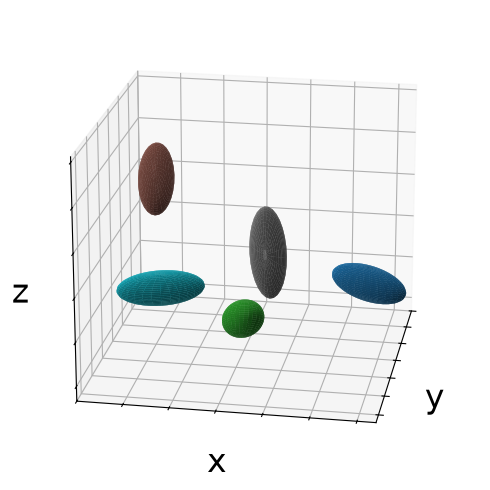

In [14]:
seed_everything(SEED)
volumes = scatterers.resolve()

positions = [v.position for v in volumes]
zs = [v.get_property("z", default=0) for v in volumes]
rotations = [v.get_property("rotation", default=(0, 0, 0)) for v in volumes]
radii = [v.get_property("radius", default=(1, 1, 1)) for v in volumes]
colors = plt.cm.tab10(np.linspace(0, 1, N_PARTICLES))


def rotation_matrix(rx, ry, rz):
    """3D rotation matrix, applied in the order Rz @ Ry @ Rx."""
    Rx = np.array([[1, 0, 0], [0, np.cos(rx), -np.sin(rx)], [0, np.sin(rx), np.cos(rx)]])
    Ry = np.array([[np.cos(ry), 0, np.sin(ry)], [0, 1, 0], [-np.sin(ry), 0, np.cos(ry)]])
    Rz = np.array([[np.cos(rz), -np.sin(rz), 0], [np.sin(rz), np.cos(rz), 0], [0, 0, 1]])
    return Rz @ Ry @ Rx


fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
u_ang = np.linspace(0, 2 * np.pi, 30)
v_ang = np.linspace(0, np.pi, 30)

all_z_plot = []
for pos, z, rad, rot, c in zip(positions, zs, radii, rotations, colors):
    rad = np.array(rad)
    # Ellipsoid radii are stored as (row, col, z); swap the first two for plotting
    # in (x, y, z) order.
    a, b, cc = rad[1] / VOXEL_SIZE[0], rad[0] / VOXEL_SIZE[0], rad[2] / VOXEL_SIZE[0]
    x = a * np.outer(np.cos(u_ang), np.sin(v_ang))
    y = b * np.outer(np.sin(u_ang), np.sin(v_ang))
    zc = cc * np.outer(np.ones_like(u_ang), np.cos(v_ang))
    R = rotation_matrix(rot[2], rot[1], rot[0])
    xyz = np.stack([x, y, zc], axis=-1) @ R
    xr, yr, zr = xyz[..., 0], xyz[..., 1], xyz[..., 2]
    ax.plot_surface(xr + pos[0], yr + pos[1], zr + float(z), color=c, alpha=0.95,
                     linewidth=0, antialiased=True, shade=True)
    r = np.max(np.array(rad) / VOXEL_SIZE[0])
    all_z_plot += [float(z) - r, float(z) + r]

xlim = (0, TILE_SIZE)
ylim = (0, TILE_SIZE)
zlim = (min(all_z_plot), max(all_z_plot) + 3)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_zlim(*zlim)
ax.set_box_aspect((xlim[1] - xlim[0], ylim[1] - ylim[0], zlim[1] - zlim[0]))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlabel("y", fontsize=24)
ax.set_ylabel("x", fontsize=24)
ax.set_zlabel("z", fontsize=24)
ax.view_init(elev=20, azim=10)

plt.savefig(f"{OUTPUT_DIR}/fig1a_scheme_1_scatterer.png", bbox_inches="tight", dpi=150, transparent=True)
plt.tight_layout()
plt.show()


## 2. Dynamics

A representative Brownian trajectory for each particle, generated directly with NumPy for simplicity. In an actual simulation, the same kind of trajectory drives a `dt.Sequential`/`dt.Sequence` pipeline so that each step is rendered as a frame.


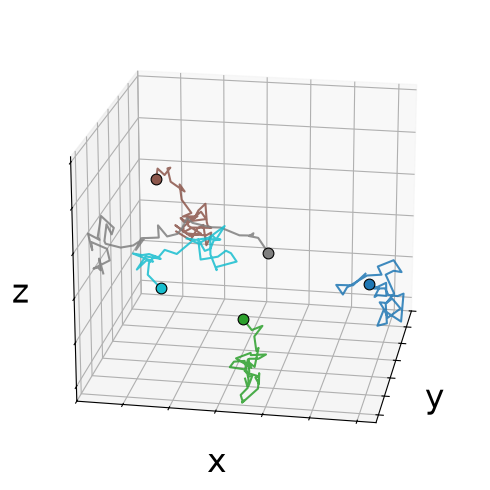

In [15]:
N_STEPS = 40
STEP_SIZE = 1.0  # pixels per step

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

for pos, z0, c in zip(positions, zs, colors):
    trajectory = np.zeros((N_STEPS, 3))
    trajectory[0] = [pos[0], pos[1], z0]
    for t in range(1, N_STEPS):
        trajectory[t] = trajectory[t - 1] + np.random.randn(3) * STEP_SIZE
    ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], color=c, lw=1.5, alpha=0.85)
    ax.scatter(*trajectory[0], color=c, s=60, edgecolor="black", linewidth=0.8, zorder=5)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_zlim(*zlim)
ax.set_box_aspect((xlim[1] - xlim[0], ylim[1] - ylim[0], zlim[1] - zlim[0]))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlabel("y", fontsize=24)
ax.set_ylabel("x", fontsize=24)
ax.set_zlabel("z", fontsize=24)
ax.view_init(elev=20, azim=10)

plt.savefig(f"{OUTPUT_DIR}/fig1a_scheme_2_dynamics.png", bbox_inches="tight", dpi=150, transparent=True)
plt.tight_layout()
plt.show()


## 3. Image Formation, Aberrations, and Acquisition

The same sample is imaged three ways, always re-seeding beforehand so that all three images share the same particle realization:

1. **Image formation** -- clean `dt.Fluorescence`, no pupil aberration, no noise.
2. **Aberrations** -- same optics, with a `dt.SphericalAberration` pupil.
3. **Acquisition** -- the aberrated image, with `dt.Poisson` and `dt.Gaussian` detector noise added on top via `>>`.

If you change the optics parameters, check for the sampling warning that DeepTrack2 raises when the Nyquist criterion is violated, and adjust `resolution` or `magnification` accordingly.


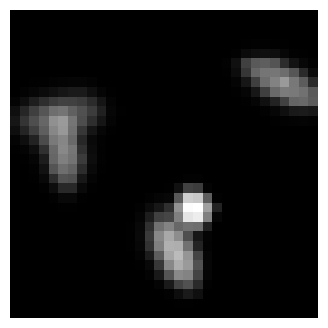

In [16]:
def save_gray(image, name):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(np.squeeze(image), cmap="gray")
    ax.axis("off")
    plt.savefig(f"{OUTPUT_DIR}/{name}.png", bbox_inches="tight", dpi=150)
    plt.show()


optics = dt.Fluorescence(
    NA=1.0,
    wavelength=0.55e-6,
    resolution=RESOLUTION,
    magnification=1,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)

# 1. Image formation.
image_formation = optics(scatterers)
seed_everything(SEED)
image_clean = image_formation.update().resolve()
save_gray(image_clean, "fig1a_scheme_3_image_formation")


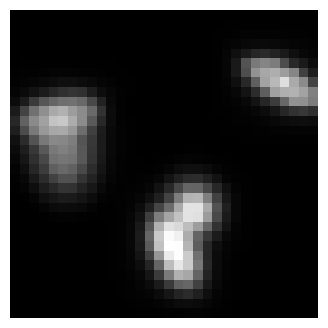

In [17]:
# 2. Aberrations.
aberration = dt.SphericalAberration(coefficient=1.5)
optics_aberrated = dt.Fluorescence(
    pupil=aberration,
    NA=1.0,
    wavelength=0.55e-6,
    resolution=RESOLUTION,
    magnification=1,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)
pipeline_aberrated = optics_aberrated(scatterers)
seed_everything(SEED)
image_aberrated = pipeline_aberrated.update().resolve()
save_gray(image_aberrated, "fig1a_scheme_4_aberrations")


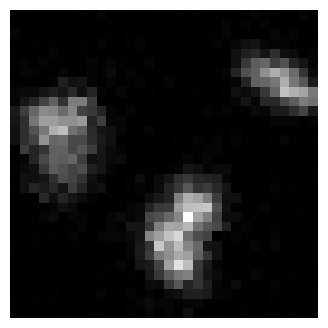

In [18]:
# 3. Acquisition: Poisson + Gaussian detector noise on top of the aberrated image.
noisy_pipeline = pipeline_aberrated >> dt.Poisson(snr=15) >> dt.Gaussian(sigma=0.01)
seed_everything(SEED)
image_noisy = noisy_pipeline.update()()
save_gray(image_noisy, "fig1a_scheme_5_acquisition")


## 4. Annotation

White background, colored shapes at the *exact* positions, radii, and rotations used to build the scatterers above -- no detection or segmentation is involved, since the ground truth is already known from the simulation parameters themselves.


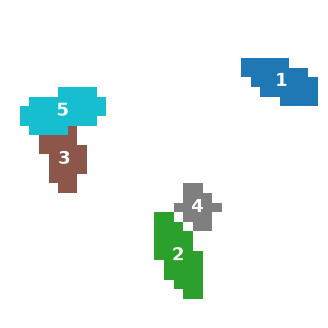

In [19]:
def get_mask(radius):
    def inner(mask):
        mask = np.sum(mask, -1, keepdims=True) > 0
        mask = np.pad(mask, [(1, 1), (1, 1), (0, 0)], mode="constant")
        mask = skmorph.isotropic_erosion(mask, radius=radius)
        return mask[1:-1, 1:-1]
    return inner


seed_everything(SEED)
resolved = scatterers.resolve()

# Build a per-particle mask so that each particle gets its own label id
# (dt.SampleToMasks with merge_method="or" alone only gives a single binary mask).
label_image = np.zeros((TILE_SIZE, TILE_SIZE), dtype=int)
for i, v in enumerate(resolved):
    pos = v.position
    z = v.get_property("z", default=0)
    rad = v.get_property("radius", default=(1, 1, 1))
    rot = v.get_property("rotation", default=(0, 0, 0))
    single = dt.Ellipsoid(
        radius=tuple(rad),
        rotation=tuple(rot),
        position=tuple(pos),
        position_unit="pixel",
        z=z,
        refractive_index=1.45,
    )
    mask_pipeline = (
        single
        >> dt.SampleToMasks(get_mask, radius=0, output_region=optics.output_region,
                             merge_method="or")
        >> dt.AsType("float")
    )
    with u.context(create_context(*VOXEL_SIZE, 1, 1, 1)):
        mask_pipeline.update()
        mask = np.asarray(mask_pipeline())[..., 0] > 0
    label_image[mask] = i + 1

composite_gt = label2rgb(label_image, colors=colors[:, :3], bg_label=0, bg_color=(1, 1, 1))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(composite_gt, origin="upper")
for i in range(1, label_image.max() + 1):
    ys, xs = np.where(label_image == i)
    ax.text(xs.mean(), ys.mean(), str(i), color="white", fontsize=13,
             fontweight="bold", ha="center", va="center")
ax.set_axis_off()
plt.savefig(f"{OUTPUT_DIR}/fig1a_scheme_6_annotation.png", bbox_inches="tight", dpi=150)
plt.show()
